# Separation of two inertial particles based on size

In [1]:
# This notebook contains the julia implementation of separation of two inertial particles based on size
# via the viscous streaming phenomenon 
# (refer the paper listed here https://github.com/quasarsrus/Multi-Particle-Transport-Viscous-Streaming-RL/tree/main).

In [2]:
# To download viscous streaming, use the command "Pkg.add(url = "https://github.com/jdeldre/ViscousStreaming.jl").
# Viscous Streaming is an 'older' package. There might be sub-dependencies that have version clashes.
# Preferably, run this on Julia v1.4.2.

using Pkg
using Plots
using ViscousStreaming
using HDF5
using JLD2
using FileIO
using Random

In [3]:
 Re = 40
 ϵ = 0.1
 Ω = 1.0 # frequency (keep this equal to 1)
 Tp = 2π/Ω # one period of oscillation
 p = StreamingParams(ϵ,Re)

 Tmax = 50*Tp

 Δx = 0.02
 xlim = (-2.8,2.8)
 ylim = (-2.8,2.8)
 n = 75
 body = Circle(0.2,n)

Circular body with 72 points and radius 0.2
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


In [4]:
# Change these values to increase or decrease the radius (τ) or the mass (β) of
# the inertial particles.

 τ1 = 0.4 # Stokes number, should be small
 β1 = 1.0 # Density parameter. Less than 1 means heavier than fluid.
 p_inert1 = InertialParameters(tau=τ1,beta=β1,epsilon=ϵ,Re=Re)

 τ2 = 0.1 # Stokes number, should be small
 β2 = 1.0 # Density parameter. Less than 1 means heavier than fluid.
 p_inert2 = InertialParameters(tau=τ2,beta=β2,epsilon=ϵ,Re=Re)

InertialParameters(1.0, 0.1, 0.1, 40)

In [5]:
 bl = BodyList()
 bL1 = deepcopy(body)
 bL2 = deepcopy(body)
 bR1 = deepcopy(body)
 bR2 = deepcopy(body)

Circular body with 72 points and radius 0.2
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


In [6]:
#Square
# left 1 cylinder
cent = (-2.0,2.0)
 α = 0.0
TL1 = RigidTransform(cent,α)
TL1(bL1) # transform the body to the current configuration

# left 2 cylinder
cent = (-2.0,-2.0)
 α = 0.0
TL2 = RigidTransform(cent,α)
TL2(bL2) # transform the body to the current configuration

# right 1 cylinder
cent = (2.0,2.0)
 α = 0.0
TR1 = RigidTransform(cent,α)
TR1(bR1) # transform the body to the current configuration

# right 2 cylinder
cent = (2.0,-2.0)
 α = 0.0
TR2 = RigidTransform(cent,α)
TR2(bR2) # transform the body to the current configuration


push!(bl,bL1);
push!(bl,bL2);
push!(bl,bR1);
push!(bl,bR2);

In [7]:
@time solver2 = FrequencyStreaming(Re,ϵ,Δx,xlim,ylim,bl);

 36.827709 seconds (1.23 G allocations: 54.749 GiB, 9.90% gc time)


In [8]:
# 4-Cylinder

ampvec = [ComplexF64[0.0,0.0] for i in 1:length(bl)];
 ampvec[1] = [1,0];  a2 = deepcopy(ampvec);
 ampvec[2] = [1,0];  a3 = deepcopy(ampvec); 
 ampvec[3] = [1,0];  a4 = deepcopy(ampvec); 
 ampvec[4] = [1,0];  a5 = deepcopy(ampvec);
 ampvec[1] = [0,0];  a6 = deepcopy(ampvec);
 ampvec[2] = [0,0];  a7 = deepcopy(ampvec);
 ampvec[3] = [0,0];  a8 = deepcopy(ampvec);
 ampvec[2] = [1,0];  a9 = deepcopy(ampvec);
 ampvec[1] = [1,0];  a10 = deepcopy(ampvec);
 ampvec[2] = [0,0];  a11 = deepcopy(ampvec);
 ampvec[3] = [1,0];  a12 = deepcopy(ampvec);
 ampvec[4] = [0,0];  a13 = deepcopy(ampvec);
 ampvec[1] = [0,0];  a14 = deepcopy(ampvec);
 ampvec[2] = [1,0];  a15 = deepcopy(ampvec);
 ampvec[3] = [0,0];  a16 = deepcopy(ampvec);

 actionspace = [a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12, a13, a14, a15, a16];

In [9]:
strdVuxy1 = []
strdVvxy1 = []
for i = 1: length(actionspace)
    soln = solver2(actionspace[i],bl);
    isoln = inertial_velocity(soln,p_inert1);
    v̄L = lagrangian_mean_velocity(isoln);
    v̄Luxy, v̄Lvxy = interpolatable_field(v̄L,isoln.g);
    push!(strdVuxy1,v̄Luxy)
    push!(strdVvxy1,v̄Lvxy)
end

strdVuxy2 = []
strdVvxy2 = []
for i = 1: length(actionspace)
    soln = solver2(actionspace[i],bl);
    isoln = inertial_velocity(soln,p_inert2);
    v̄L = lagrangian_mean_velocity(isoln);
    v̄Luxy, v̄Lvxy = interpolatable_field(v̄L,isoln.g);
    push!(strdVuxy2,v̄Luxy)
    push!(strdVvxy2,v̄Lvxy)
end

In [10]:
function mean_motion(dR,R,p,t,v̄Luxy,v̄Lvxy)
    dR[1] = v̄Luxy(R[1],R[2])
    dR[2] = v̄Lvxy(R[1],R[2])
   return dR
end

mean_motion (generic function with 1 method)

In [11]:
function sequence(pos)
    if pos[1] >= 0 && pos[2] >= 0
        return [1, 10, 4]
    elseif pos[1] < 0 && pos[2] >= 0
        return [13, 14, 4]
    elseif pos[1] < 0 && pos[2] < 0
        return [7, 10, 4]
    else
        return [15, 14, 4]
    end
end 

function reset_position()

    posx_1 = trunc(3.2*rand() - 1.6, digits = 5)
    posy_1 = trunc(3.2*rand() - 1.6, digits = 5)

    posx_2 = trunc(posx_1 + 0.1*rand() - 0.05, digits = 5)
    posy_2 = trunc(posy_1 + 0.1*rand() - 0.05, digits = 5)

    return (posx_1, posy_1), (posx_2, posy_2)
    
end

reset_position (generic function with 1 method)

In [12]:
function particle_separator(pos1, pos2)
    done = false

    println(pos1, pos2)

    part1_posx = []
    part1_posy = []
    part2_posx = []
    part2_posy = []

    phase_lengths_action_choices = []
    phase_length_ctr = 0

    step = sequence(pos1)
    j = 1
    multiplier = 1000
    while !done

        v̄Lfcn1(dR,R,p,t) = mean_motion(dR,R,p,t,strdVuxy1[step[j]],strdVvxy1[step[j]])
        v̄Lfcn2(dR,R,p,t) = mean_motion(dR,R,p,t,strdVuxy2[step[j]],strdVvxy2[step[j]])

        soln1 = solver2(actionspace[step[j]],bl);    
        soln2 = solver2(actionspace[step[j]],bl);

        Tmax1 = multiplier * Tp
        solL1 = compute_trajectory(v̄Lfcn1,pos1,Tmax1,10Tp,bl=bl,ϵ=p.ϵ);
        push!(part1_posx, solL1[1,:])
        push!(part1_posy, solL1[2,:])
        pos1 = (last(solL1[1,:]),last(solL1[2,:]))
        phase_length_ctr += length(solL1[1,:])
        #println(length(solL1[1,:]))

        Tmax2 = multiplier * Tp
        solL2 = compute_trajectory(v̄Lfcn2,pos2,Tmax2,10Tp,bl=bl,ϵ=p.ϵ);
        push!(part2_posx, solL2[1,:])
        push!(part2_posy, solL2[2,:])
        pos2 = (last(solL2[1,:]),last(solL2[2,:]))

        distance = sqrt((pos2[1]-pos1[1])^2+(pos2[2]-pos1[2])^2)

        println(distance)

        #println(step[j],"g")

        if j==1
            if (distance > 0.7)
                j += 1
                multiplier = 500
                println(length(part1_posx[end]))
                push!(phase_lengths_action_choices, (phase_length_ctr, step[j-1]))
                #phase_length_ctr = 0
            else
            end 
        elseif j==2
            if (distance > 2.0)
                j += 1
                multiplier = 10000
                println(length(part1_posx[end]))
                push!(phase_lengths_action_choices, (phase_length_ctr, step[j-1]))
                #phase_length_ctr = 0
            else
            end  
        elseif j==3
            if (distance > 2.5)
                done = true
                push!(phase_lengths_action_choices, (phase_length_ctr, step[j]))
            else
            end 
        end
    end
    return part1_posx, part1_posy, part2_posx, part2_posy, phase_lengths_action_choices
end

particle_separator (generic function with 1 method)

In [13]:
p1x, p1y, p2x, p2y, info = particle_separator(reset_position()...);

(-0.51221, 0.6052)(-0.53439, 0.59925)
1.3341211551585335
201
2.769828531249635
101
4.193057539241673


In [14]:
soln_1 = solver2(actionspace[info[1][2]],bl);
soln_2 = solver2(actionspace[info[2][2]],bl);
soln_3 = solver2(actionspace[info[3][2]],bl);

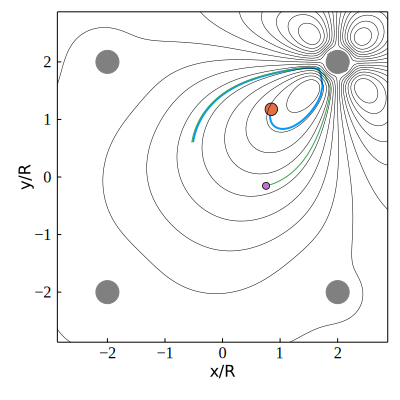

In [15]:
p1x = reduce(vcat,p1x);
p1y = reduce(vcat,p1y);
p2x = reduce(vcat,p2x);
p2y = reduce(vcat,p2y);

ps = plot(p1x[1:info[1][1]],p1y[1:info[1][1]],ratio=1,legend=false,linewidth=2,xlim=xlim ,ylim=ylim,
    label="Particle trajectory",xlabel="x/R",ylabel="y/R",tickfont=font(10,"Times"),size=(400,400))
scatter!([p1x[info[1][1]]], [p1y[info[1][1]]], markersize = 7.0:7.0)
plot!(p2x[1:info[1][1]],p2y[1:info[1][1]])
scatter!([p2x[info[1][1]]], [p2y[info[1][1]]])
plot!(ps,lagrangian_mean_streamfunction(soln_1),soln_1.g,levels=15,color=:black,linewidth=0.5)
plot!(ps,bl,fillcolor=:gray,linecolor=:gray)
display(ps)
#savefig(ps,"two_part_sep_1.png")

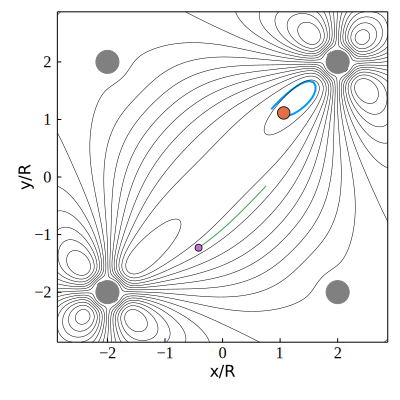

In [16]:
ps = plot(p1x[info[1][1]:info[2][1]],p1y[info[1][1]:info[2][1]],ratio=1,legend=false,linewidth=2,xlim=xlim ,ylim=ylim,
    label="Particle trajectory",xlabel="x/R",ylabel="y/R",tickfont=font(10,"Times"),size=(400,400))
scatter!([p1x[info[2][1]]], [p1y[info[2][1]]], markersize = 7.0:7.0)
plot!(p2x[info[1][1]:info[2][1]],p2y[info[1][1]:info[2][1]])
scatter!([p2x[info[2][1]]], [p2y[info[2][1]]])
plot!(ps,lagrangian_mean_streamfunction(soln_2),soln_2.g,levels=15,color=:black,linewidth=0.5)
plot!(ps,bl,fillcolor=:gray,linecolor=:gray)
display(ps)
#savefig(ps,"two_part_sep_2.png")

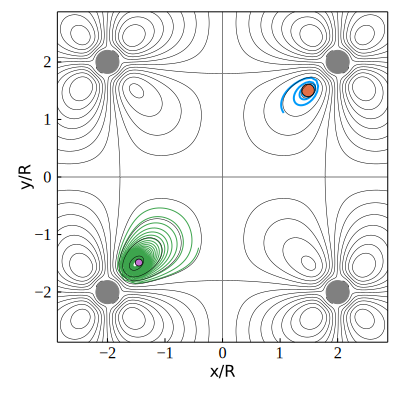

In [17]:
ps = plot(p1x[info[2][1]:end],p1y[info[2][1]:end],ratio=1,legend=false,linewidth=2,xlim=xlim ,ylim=ylim,
    label="Particle trajectory",xlabel="x/R",ylabel="y/R",tickfont=font(10,"Times"),size=(400,400))
scatter!([p1x[end]], [p1y[end]], markersize = 7.0:7.0)
plot!(p2x[info[2][1]:end],p2y[info[2][1]:end])
scatter!([p2x[end]], [p2y[end]])
plot!(ps,lagrangian_mean_streamfunction(soln_3),soln_3.g,levels=15,color=:black,linewidth=0.5)
plot!(ps,bl,fillcolor=:gray,linecolor=:gray)
display(ps)
#savefig(ps,"two_part_sep_3.png")